In [11]:
import os
import warnings
warnings.filterwarnings("ignore")
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools import TavilySearchResults
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, MessagesState
from langchain_core.tools import tool
from typing import Literal
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import Graph

In [12]:
load_dotenv()

True

In [13]:
embeddings = OpenAIEmbeddings()
parser = StrOutputParser()
llm = ChatOpenAI()

In [14]:
def function1(input1):
    return input1 + "from first function"

def function2(input2):
    return input2 + " and jain from second function"

In [15]:
workflow = Graph()

In [16]:
workflow.add_node("function1", function1)
workflow.add_node("function2", function2)
workflow.add_edge("function1", "function2")
workflow.set_entry_point("function1")
workflow.set_finish_point("function2")


In [17]:
app = workflow.compile()

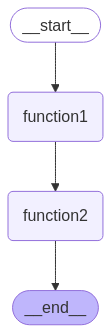

In [18]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [19]:
app.invoke("Hi! It's Shubh")

"Hi! It's Shubhfrom first function and jain from second function"

In [ ]:
for output in app.stream("Hi! It's Shubh"):
    for key, value in output.items(): #key is the node name
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from function1
_______
Hi! It's Shubhfrom first function


here is output from function2
_______
Hi! It's Shubhfrom first function and jain from second function




In [21]:
def llm_function(input):
    return llm.invoke(input).content

def upper_case_helper(input):
    return input.upper()

In [22]:
workflow = Graph()
workflow.add_node("llm_function", llm_function)
workflow.add_node("upper_case_helper", upper_case_helper)
workflow.add_edge("llm_function", "upper_case_helper")
workflow.set_entry_point("llm_function")
workflow.set_finish_point("upper_case_helper")
app = workflow.compile()

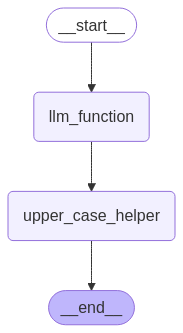

In [23]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [24]:
for output in app.stream("Hi! It's Shubh"):
    for key, value in output.items(): #key is the node name
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from llm_function
_______
Hello Shubh! How can I assist you today?


here is output from upper_case_helper
_______
HELLO SHUBH! HOW CAN I ASSIST YOU TODAY?


